Data scrapping and cleaning


In [1]:
import requests
import pandas as pd
from bs4 import Comment
from bs4 import BeautifulSoup

In [ ]:
import os

data_folder = "C:/Users/USER/Desktop/thesis/final_code_data/data"
files = os.listdir(data_folder)
print("Files in data folder:", files)

nba_data_path = os.path.join(data_folder, "nba_data.csv")
game_data_path = os.path.join(data_folder, "game_data.csv")

from pandas.errors import EmptyDataError

try:
	nba_data = pd.read_csv(nba_data_path)
	print("nba_data shape:", nba_data.shape)
	print(nba_data.head())
except EmptyDataError:
	print("nba_data.csv is empty.")
	nba_data = pd.DataFrame()

try:
	game_data = pd.read_csv(game_data_path)
	print("game_data shape:", game_data.shape)
	print(game_data.head())
except EmptyDataError:
	print("game_data.csv is empty.")
	game_data = pd.DataFrame()

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 2-3: truncated \UXXXXXXXX escape (2909377879.py, line 3)

In [ ]:
# Make sure df2 is defined
df2 = game_data

# Match the stats for each team in the record for each game
title = df.columns.tolist()[30:50]
h_stats = [[] for x in range(len(title))]
a_stats = [[] for x in range(len(title))]

yr = df2['yearID'].tolist()
hn = df2['home_team'].tolist()
an = df2['away_team'].tolist()

for i in range(len(yr)):
    h_item = df[(df.Team == hn[i]) & (df.yearID == yr[i])]
    a_item = df[(df.Team == an[i]) & (df.yearID == yr[i])]
    for j in range(len(title)):
        h_val = h_item[title[j]].tolist()
        h_stats[j].append(h_val[0])
        
        a_val = a_item[title[j]].tolist()
        a_stats[j].append(a_val[0])
        
for index, item in enumerate(title):
    h_item = 'h_' + item
    a_item = 'a_' + item
    df2[h_item] = h_stats[index]
    df2[a_item] = a_stats[index]

In [ ]:
df2['yearID'] = df2['yearID'].astype('int64')
df2

,yearID,home_team,away_team,home_win,h_FG,a_FG,h_FGA,a_FGA,h_FG%,a_FG%,...,h_AST,a_AST,h_STL,a_STL,h_BLK,a_BLK,h_TOV,a_TOV,h_PF,a_PF
0,2000,Orlando Magic,Charlotte Hornets,0,38.6,35.8,85.5,79.7,0.452,0.449,...,20.8,24.7,9.1,8.9,5.7,5.9,17.6,14.7,24.0,20.4
1,2000,Golden State Warriors,Dallas Mavericks,0,36.5,39.0,87.1,85.9,0.420,0.453,...,22.6,22.1,8.9,7.2,4.3,5.1,15.9,13.7,24.9,21.6
2,2000,Phoenix Suns,Denver Nuggets,0,37.7,37.3,82.6,84.3,0.457,0.442,...,25.6,23.3,9.1,6.8,5.3,7.5,16.7,15.6,24.1,23.9
3,2000,Milwaukee Bucks,Houston Rockets,1,38.7,36.6,83.3,81.3,0.465,0.450,...,22.6,21.6,8.2,7.5,4.6,5.3,15.0,17.4,24.6,20.3
4,2000,Seattle SuperSonics,Los Angeles Clippers,1,37.9,35.1,84.7,82.4,0.447,0.426,...,22.9,18.0,8.0,7.0,4.2,6.0,14.0,16.2,21.7,22.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1235,2019,Utah Jazz,Minnesota Timberwolves,0,40.4,41.6,86.4,91.3,0.468,0.456,...,26.0,24.6,8.1,8.3,5.9,5.0,15.1,13.1,21.1,20.3
1236,2019,Indiana Pacers,New York Knicks,1,41.3,38.2,87.0,88.3,0.475,0.433,...,26.0,20.1,8.7,6.8,4.9,5.1,13.7,14.0,19.4,20.9
1237,2019,New Orleans Pelicans,Golden State Warriors,0,43.7,44.0,92.2,89.8,0.473,0.491,...,27.0,29.4,7.4,7.6,5.4,6.4,14.8,14.3,21.1,21.4
1238,2019,Dallas Mavericks,Los Angeles Lakers,0,38.8,42.6,86.9,90.5,0.447,0.470,...,23.4,25.6,6.5,7.5,4.3,5.4,14.2,15.7,20.1,20.7


In [ ]:
df.to_csv(r"C:/Users/USER/Desktop/thesis/cs320final/data/nba_data.csv", index = False)
df2.to_csv(r"C:/Users/USER/Desktop/thesis/cs320final/data/game_data.csv", index = False)

Library


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Matplotlib is building the font cache; this may take a moment.


Original Data


In [ ]:
import pandas as pd

# Define file path
path = "C:/Users/USER/Desktop/thesis/cs320final/data/nba_data.csv"

# Read the CSV file
data = pd.read_csv(path)

# Display first 5 rows
print(data.head())


   yearID                    Team   Age     W     L  PW  PL   MOV   SOS   SRS  \
0    2000      Los Angeles Lakers  29.2  67.0  15.0  64  18  8.55 -0.14  8.41   
1    2000  Portland Trail Blazers  29.6  59.0  23.0  59  23  6.40 -0.04  6.36   
2    2000       San Antonio Spurs  30.9  53.0  29.0  58  24  5.94 -0.02  5.92   
3    2000            Phoenix Suns  28.6  53.0  29.0  56  26  5.22  0.02  5.24   
4    2000               Utah Jazz  31.5  55.0  27.0  54  28  4.46  0.05  4.52   

   ...    FT%   ORB   DRB   TRB   AST  STL  BLK   TOV    PF    PTS  
0  ...  0.696  13.6  33.4  47.0  23.4  7.5  6.5  13.9  22.5  100.8  
1  ...  0.760  11.8  31.2  43.0  23.5  7.7  4.8  15.2  22.7   97.5  
2  ...  0.746  11.3  32.5  43.8  22.2  7.5  6.7  15.0  20.9   96.2  
3  ...  0.759  12.5  31.2  43.7  25.6  9.1  5.3  16.7  24.1   98.9  
4  ...  0.773  11.4  29.6  41.0  24.9  7.7  5.4  14.9  24.5   96.5  

[5 rows x 51 columns]


Organize Dataset


In [ ]:
import pandas as pd

# Calculate win percentage
data['WP'] = data['W'] / (data['W'] + data['L'])

# Cut yearID into 5 equal-width bins
data['year'] = pd.cut(data['yearID'], bins=5)

# Display first 5 rows
print(data.head())


   yearID                    Team   Age     W     L  PW  PL   MOV   SOS   SRS  \
0    2000      Los Angeles Lakers  29.2  67.0  15.0  64  18  8.55 -0.14  8.41   
1    2000  Portland Trail Blazers  29.6  59.0  23.0  59  23  6.40 -0.04  6.36   
2    2000       San Antonio Spurs  30.9  53.0  29.0  58  24  5.94 -0.02  5.92   
3    2000            Phoenix Suns  28.6  53.0  29.0  56  26  5.22  0.02  5.24   
4    2000               Utah Jazz  31.5  55.0  27.0  54  28  4.46  0.05  4.52   

   ...   DRB   TRB   AST  STL  BLK   TOV    PF    PTS        WP  \
0  ...  33.4  47.0  23.4  7.5  6.5  13.9  22.5  100.8  0.817073   
1  ...  31.2  43.0  23.5  7.7  4.8  15.2  22.7   97.5  0.719512   
2  ...  32.5  43.8  22.2  7.5  6.7  15.0  20.9   96.2  0.646341   
3  ...  31.2  43.7  25.6  9.1  5.3  16.7  24.1   98.9  0.646341   
4  ...  29.6  41.0  24.9  7.7  5.4  14.9  24.5   96.5  0.670732   

                 year  
0  (1999.981, 2003.8]  
1  (1999.981, 2003.8]  
2  (1999.981, 2003.8]  
3  (1999.981, 

Data Analysis


3.1 Pace vs. Wininning percentage over year


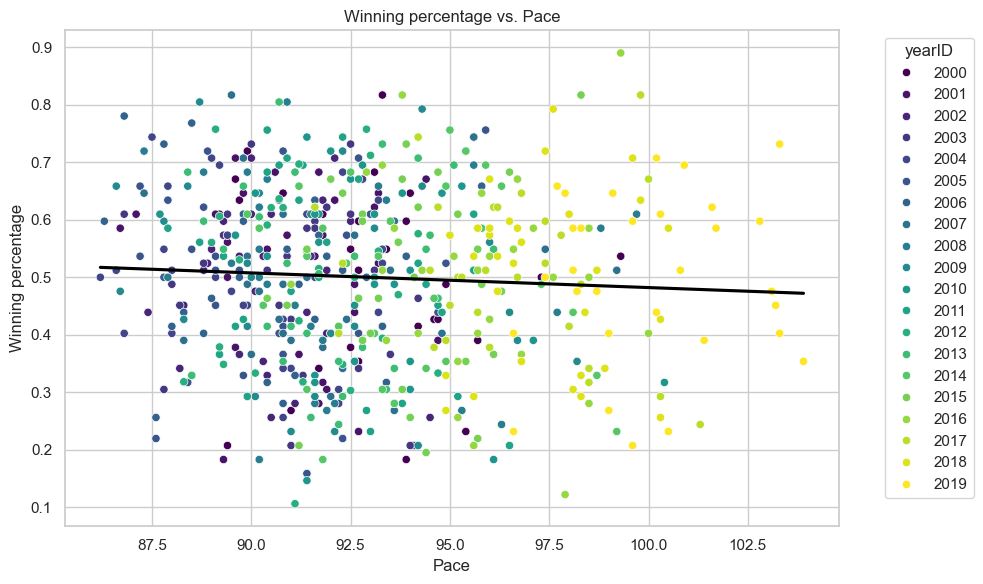

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Create scatterplot with regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Pace', y='WP', hue='yearID', palette='viridis', legend='full')
sns.regplot(data=data, x='Pace', y='WP', scatter=False, color='black', ci=None)

# Add labels and title
plt.title("Winning percentage vs. Pace")
plt.xlabel("Pace")
plt.ylabel("Winning percentage")
plt.legend(title='yearID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


3.2 relationship between Offensive rating and WP over time


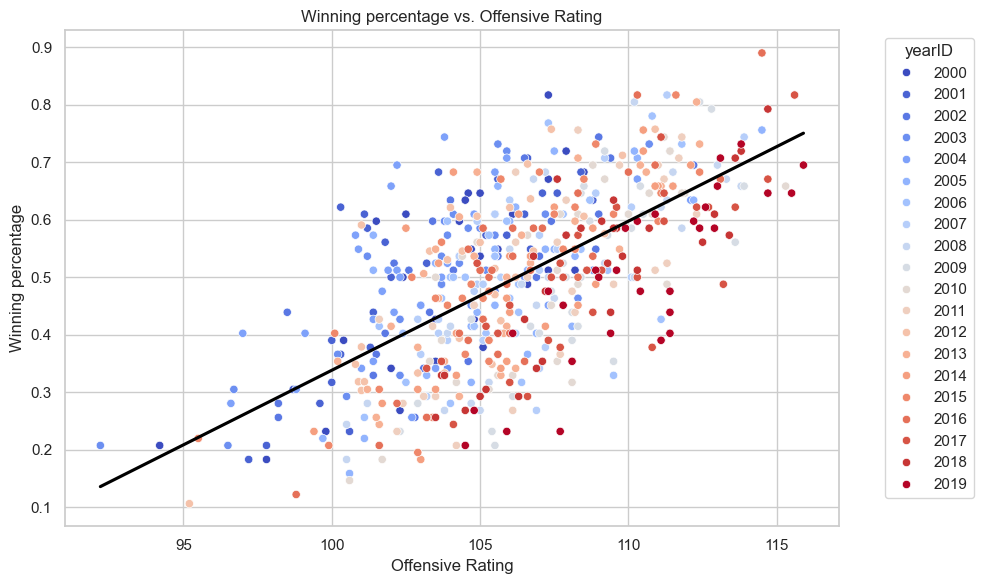

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Create scatterplot with regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='ORtg', y='WP', hue='yearID', palette='coolwarm', legend='full')
sns.regplot(data=data, x='ORtg', y='WP', scatter=False, color='black', ci=None)

# Add labels and title
plt.title("Winning percentage vs. Offensive Rating")
plt.xlabel("Offensive Rating")
plt.ylabel("Winning percentage")
plt.legend(title='yearID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


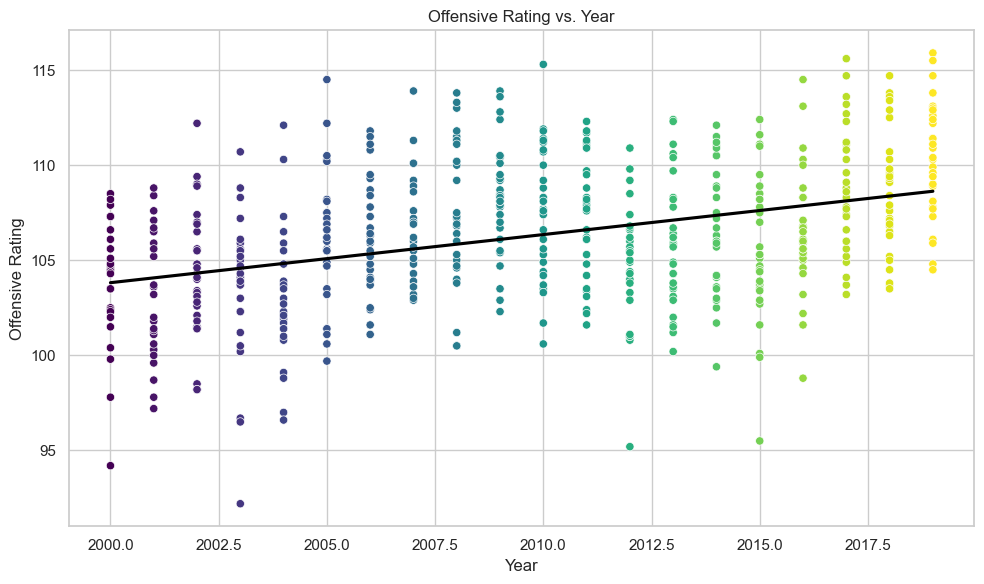

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='yearID', y='ORtg', hue='yearID', palette='viridis', legend=None)
sns.regplot(data=data, x='yearID', y='ORtg', scatter=False, color='black', ci=None)

# Customize plot
plt.title("Offensive Rating vs. Year")
plt.xlabel("Year")
plt.ylabel("Offensive Rating")
plt.tight_layout()
plt.show()


3.3 How does Three-points ball affect the game over time
3.3.0

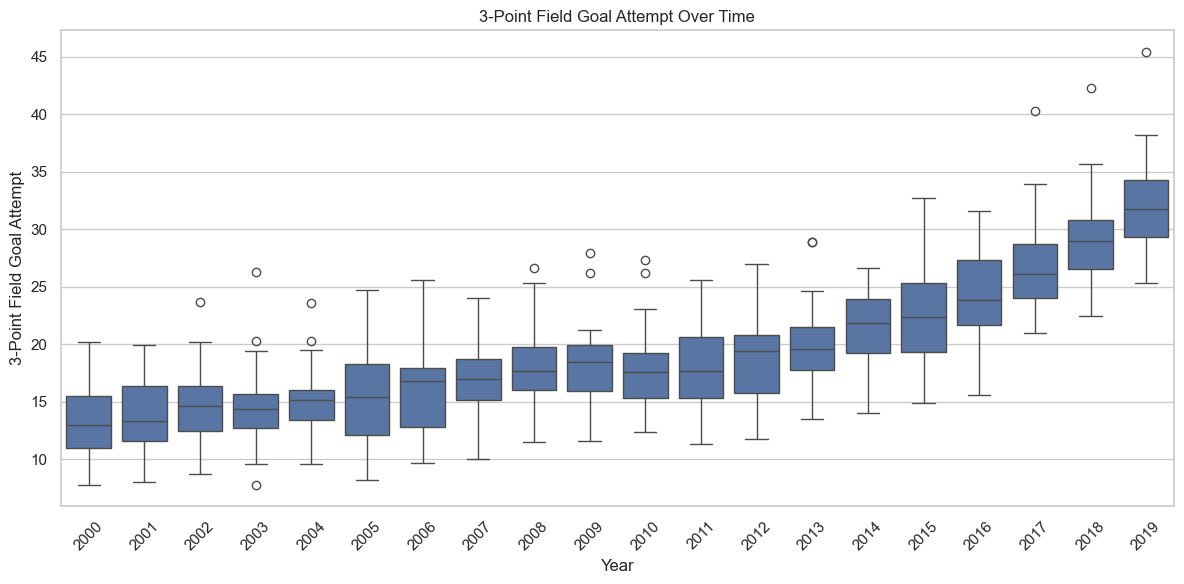

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='yearID', y='3PA')

plt.title("3-Point Field Goal Attempt Over Time")
plt.xlabel("Year")
plt.ylabel("3-Point Field Goal Attempt")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


3.3.1


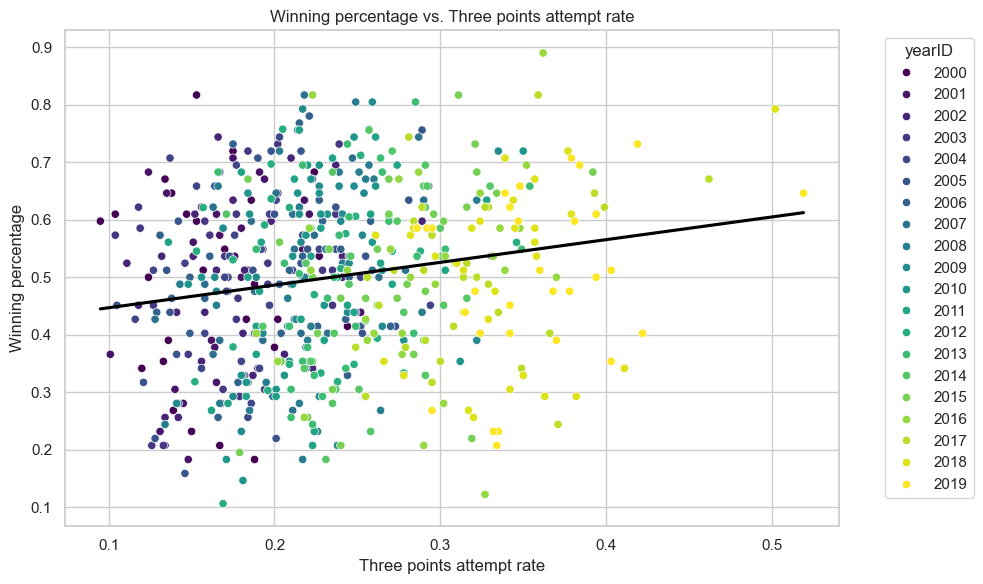

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='3PAr', y='WP', hue='yearID', palette='viridis', legend='full')
sns.regplot(data=data, x='3PAr', y='WP', scatter=False, color='black', ci=None)

# Add labels and title
plt.title("Winning percentage vs. Three points attempt rate")
plt.xlabel("Three points attempt rate")
plt.ylabel("Winning percentage")
plt.legend(title='yearID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


3.3.2

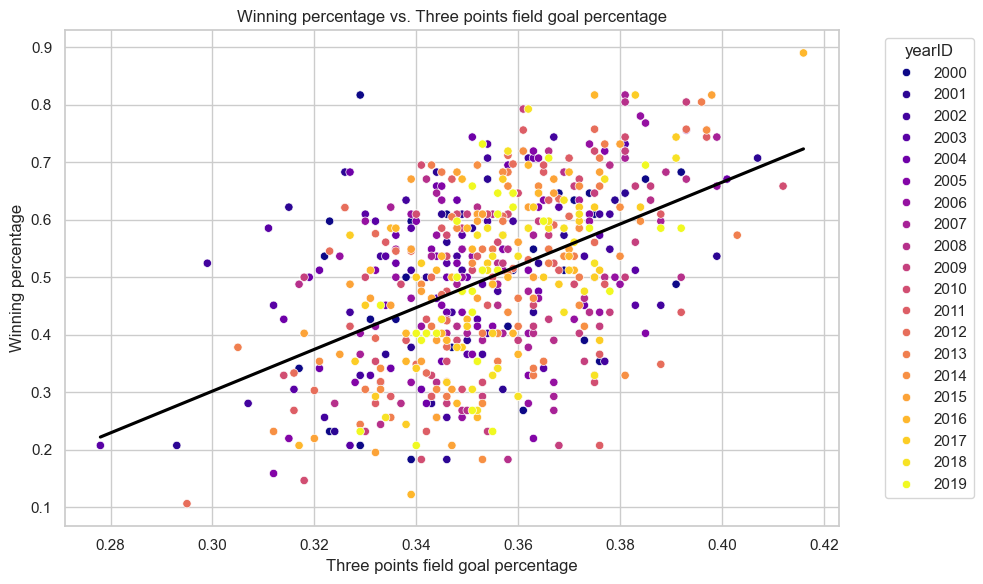

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='3P%', y='WP', hue='yearID', palette='plasma', legend='full')
sns.regplot(data=data, x='3P%', y='WP', scatter=False, color='black', ci=None)

# Customize labels and title
plt.title("Winning percentage vs. Three points field goal percentage")
plt.xlabel("Three points field goal percentage")
plt.ylabel("Winning percentage")
plt.legend(title='yearID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


3.3.3


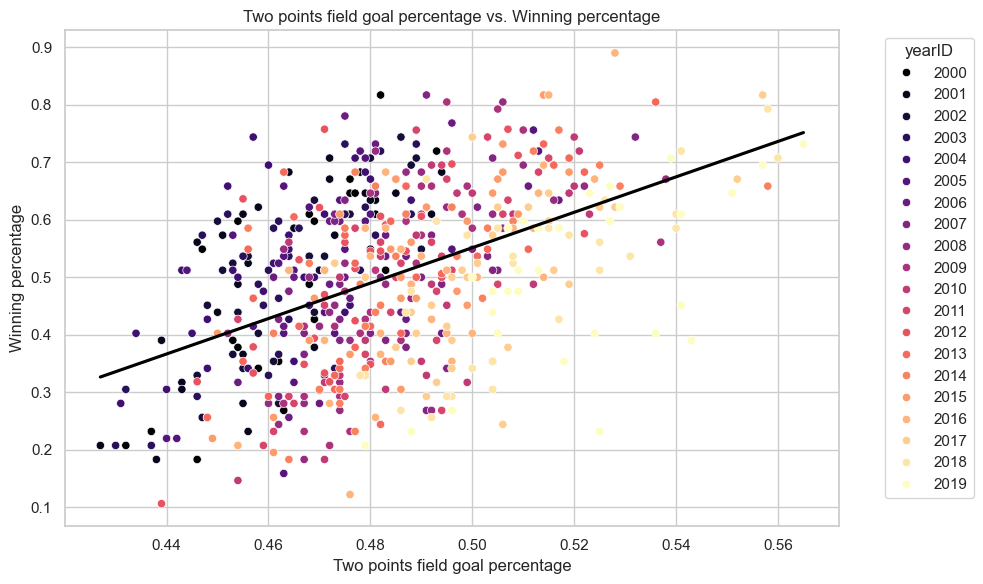

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='2P%', y='WP', hue='yearID', palette='magma', legend='full')
sns.regplot(data=data, x='2P%', y='WP', scatter=False, color='black', ci=None)

# Labels and title
plt.title("Two points field goal percentage vs. Winning percentage")
plt.xlabel("Two points field goal percentage")
plt.ylabel("Winning percentage")
plt.legend(title='yearID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


3.3.4


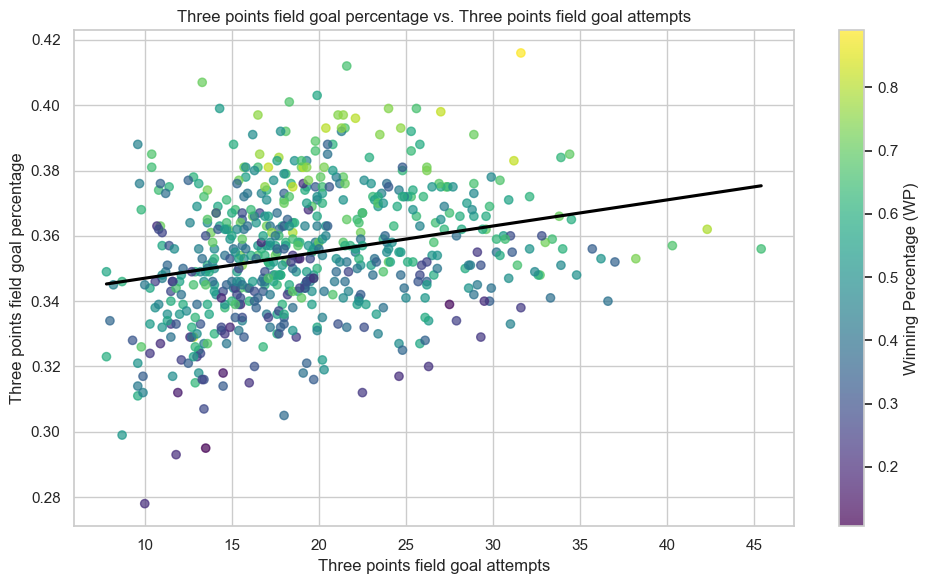

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
scatter = plt.scatter(data['3PA'], data['3P%'], c=data['WP'], cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Winning Percentage (WP)')

# Add regression line (linear model)
sns.regplot(x='3PA', y='3P%', data=data, scatter=False, color='black', ci=None)

# Labels and title
plt.title("Three points field goal percentage vs. Three points field goal attempts")
plt.xlabel("Three points field goal attempts")
plt.ylabel("Three points field goal percentage")
plt.tight_layout()
plt.show()


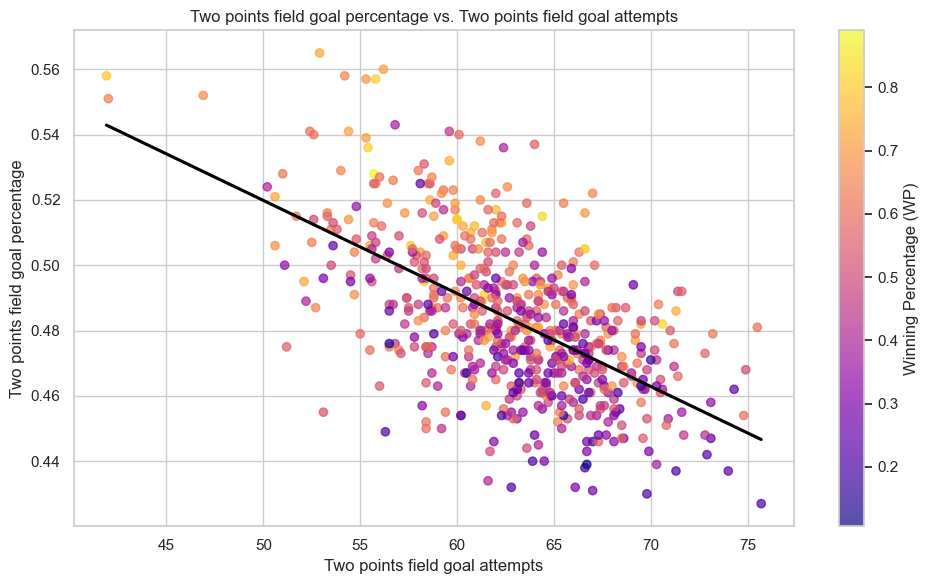

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set seaborn style
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
scatter = plt.scatter(data['2PA'], data['2P%'], c=data['WP'], cmap='plasma', alpha=0.7)
plt.colorbar(scatter, label='Winning Percentage (WP)')

# Add regression line
sns.regplot(x='2PA', y='2P%', data=data, scatter=False, color='black', ci=None)

# Labels and title
plt.title("Two points field goal percentage vs. Two points field goal attempts")
plt.xlabel("Two points field goal attempts")
plt.ylabel("Two points field goal percentage")
plt.tight_layout()
plt.show()


3.3.5


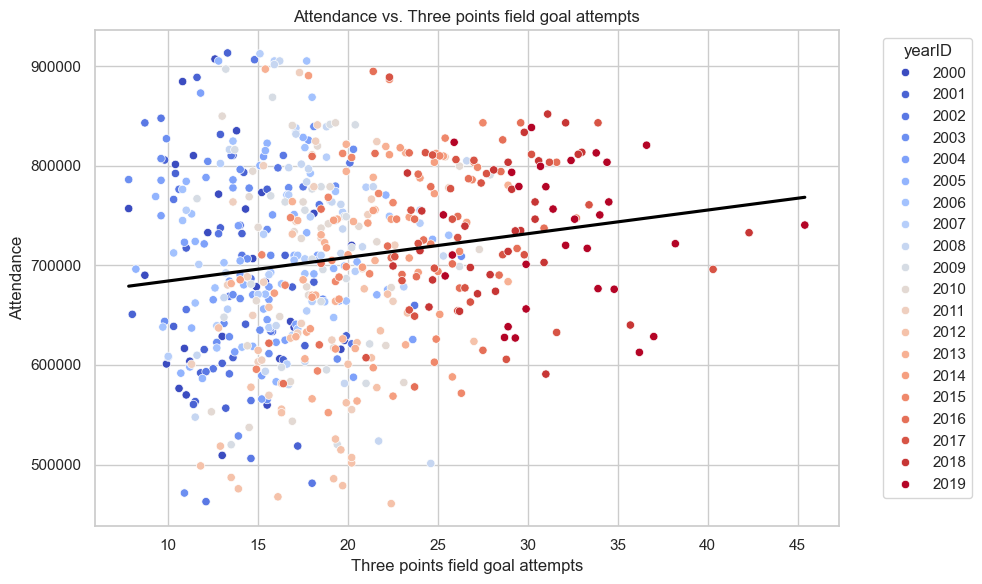

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='3PA', y='Attend.', hue='yearID', palette='coolwarm', legend='full')
sns.regplot(data=data, x='3PA', y='Attend.', scatter=False, color='black', ci=None)

plt.title("Attendance vs. Three points field goal attempts")
plt.xlabel("Three points field goal attempts")
plt.ylabel("Attendance")
plt.legend(title='yearID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


3.3.6


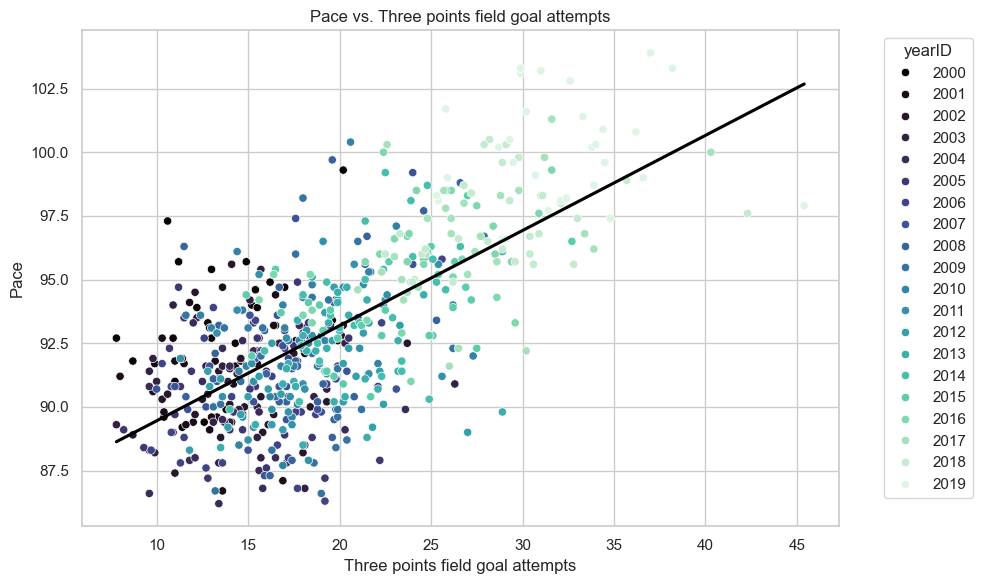

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='3PA', y='Pace', hue='yearID', palette='mako', legend='full')
sns.regplot(data=data, x='3PA', y='Pace', scatter=False, color='black', ci=None)

plt.title("Pace vs. Three points field goal attempts")
plt.xlabel("Three points field goal attempts")
plt.ylabel("Pace")
plt.legend(title='yearID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


3.3.7


3.4


3.4.1


Below graph shows Winning Percentage vs. Total Rebound Ball over year.



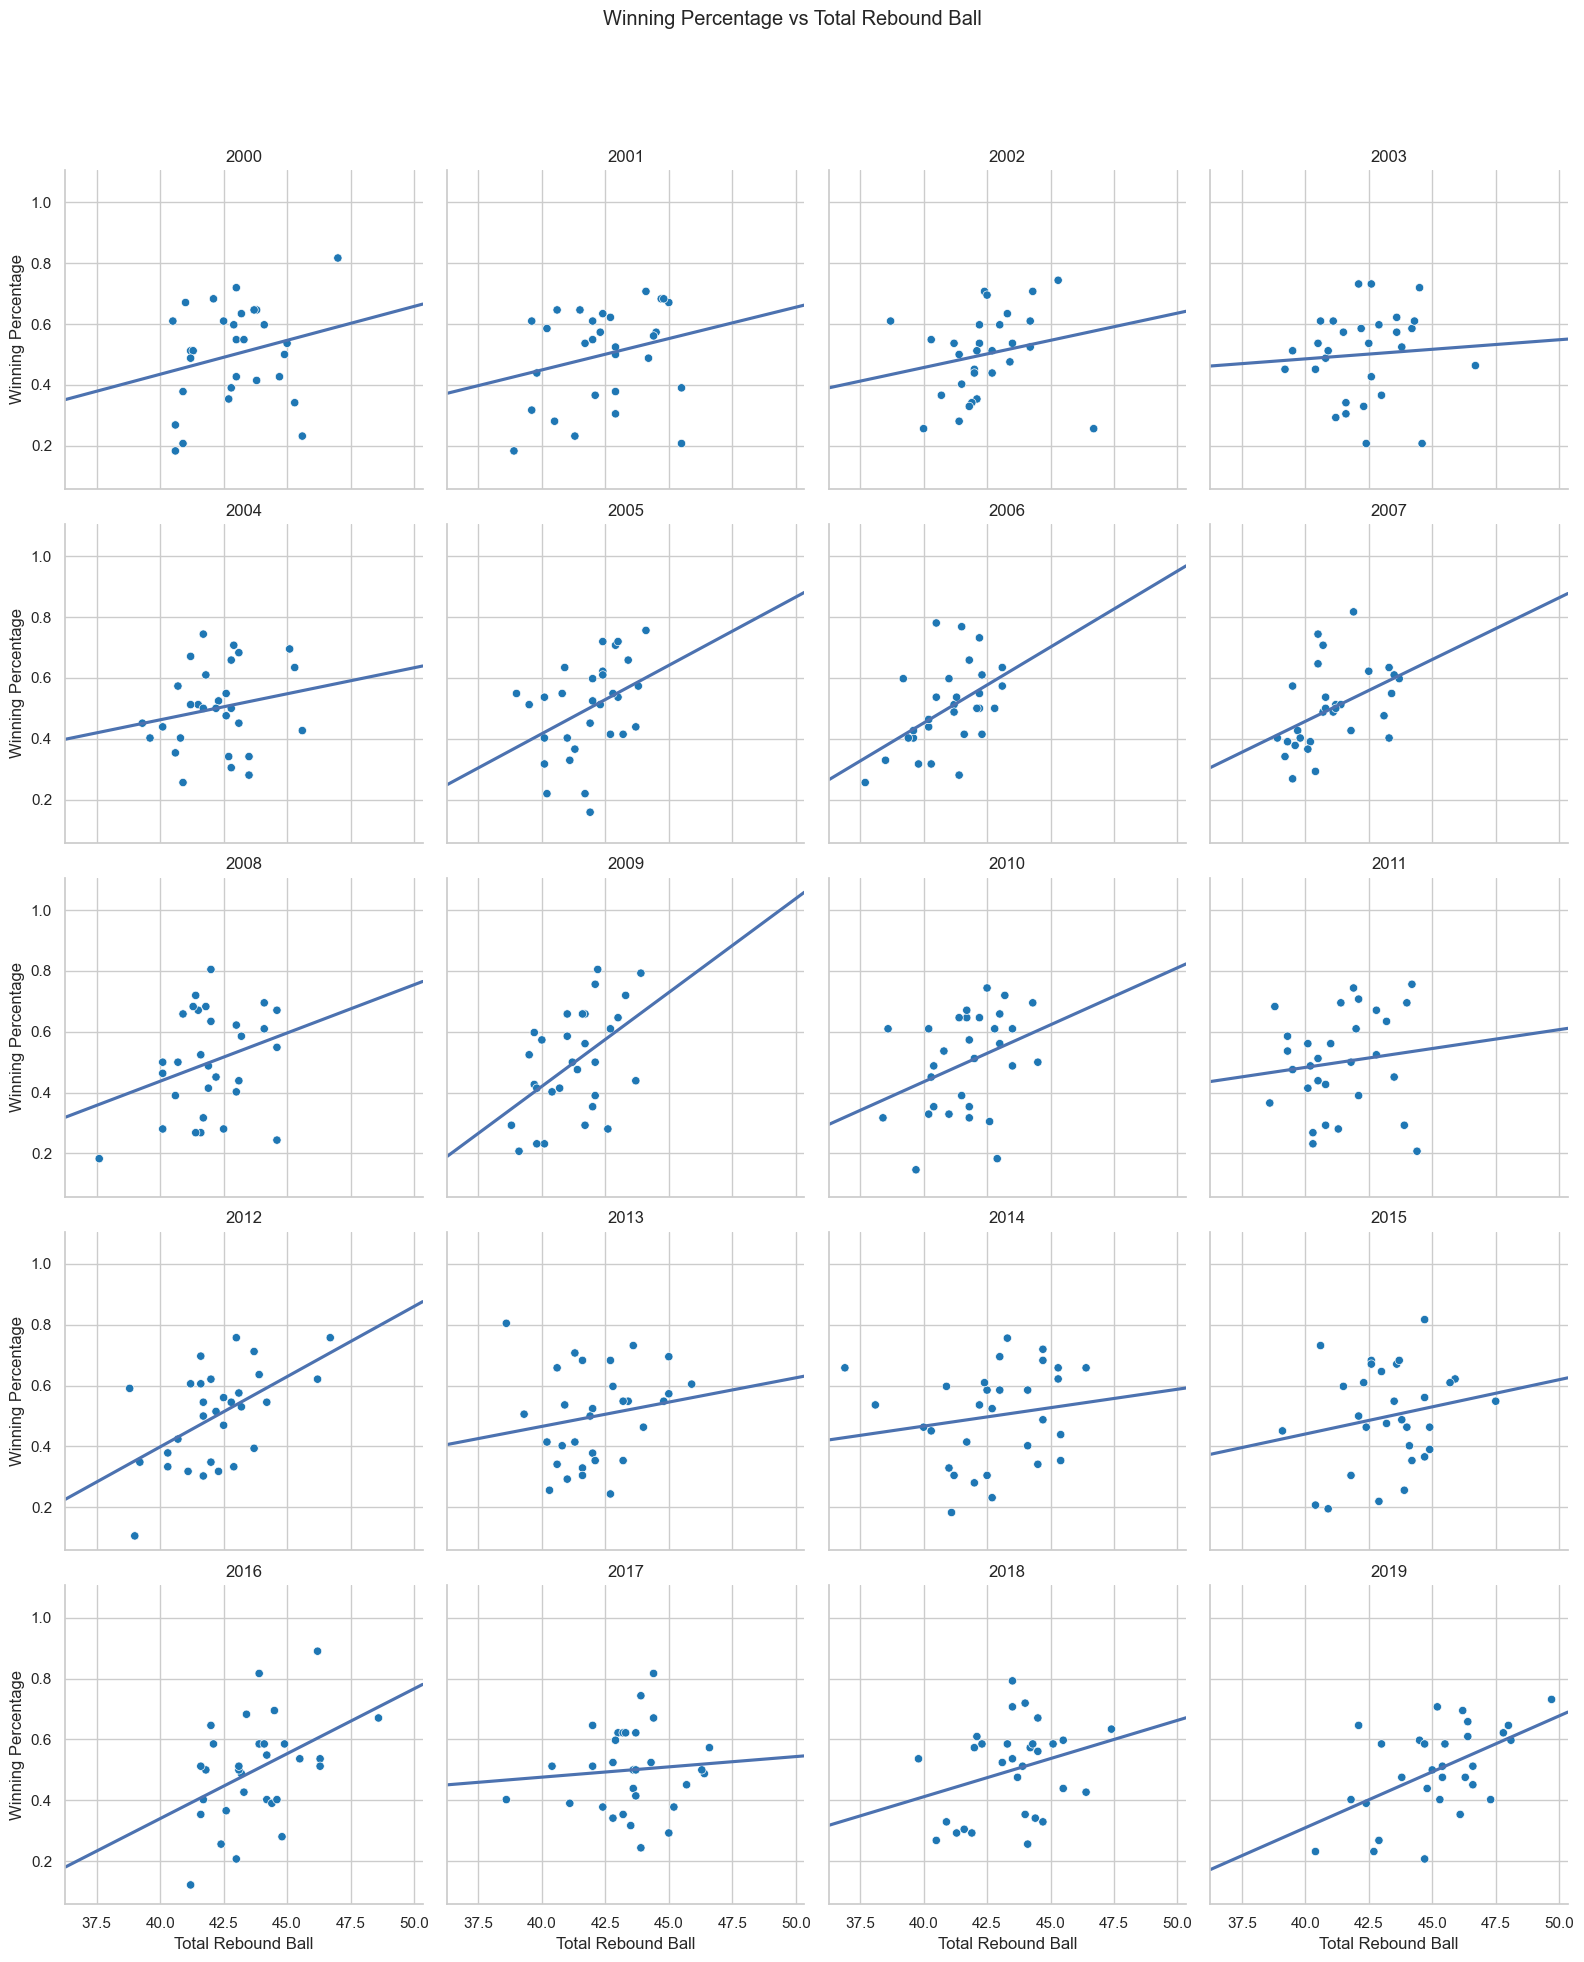

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure your dataset has 'year' column for faceting
data['year'] = data['yearID'].astype(str)  # convert if necessary

sns.set(style="whitegrid")

# Create FacetGrid, one subplot per year
g = sns.FacetGrid(data, col='year', col_wrap=4, height=4, sharex=True, sharey=True)

# Map scatterplots
g.map_dataframe(sns.scatterplot, x='TRB', y='WP', hue='year', palette='tab10', legend=False)

# Map regression lines per facet
from numpy.polynomial.polynomial import Polynomial

def regplot_per_facet(data, color, **kwargs):
    sns.regplot(x='TRB', y='WP', data=data, scatter=False, color=color, ci=None, truncate=False, **kwargs)

g.map_dataframe(regplot_per_facet)

# Adjust titles and axis labels
g.set_axis_labels("Total Rebound Ball", "Winning Percentage")
g.set_titles(col_template="{col_name}")

# Add overall title
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Winning Percentage vs Total Rebound Ball")

plt.show()


In [ ]:
import statsmodels.formula.api as smf
import pandas as pd

# Make sure 'year' is a categorical variable for interaction
data['year'] = data['yearID'].astype(str)

# Fit linear regression with interaction term
regression = smf.ols('WP ~ TRB * year', data=data).fit()

# Get tidy summary as DataFrame
model = regression.summary2().tables[1]  # coefficients table

print(model)


                     Coef.  Std.Err.         t     P>|t|    [0.025    0.975]
Intercept        -0.457172  0.695135 -0.657674  0.511020 -1.822589  0.908245
year[T.2001]      0.082064  0.931214  0.088126  0.929808 -1.747071  1.911199
year[T.2002]      0.198733  1.009382  0.196886  0.843989 -1.783943  2.181409
year[T.2003]      0.691212  0.985366  0.701477  0.483299 -1.244291  2.626715
year[T.2004]      0.234945  1.025475  0.229109  0.818869 -1.779342  2.249233
year[T.2005]     -0.922776  1.100049 -0.838850  0.401915 -3.083545  1.237992
year[T.2006]     -1.089494  1.077017 -1.011585  0.312178 -3.205022  1.026034
year[T.2007]     -0.711261  1.040821 -0.683365  0.494662 -2.755691  1.333170
year[T.2008]     -0.373715  1.010424 -0.369859  0.711628 -2.358437  1.611008
year[T.2009]     -1.590599  1.072892 -1.482535  0.138766 -3.698025  0.516826
year[T.2010]     -0.607293  1.023135 -0.593561  0.553047 -2.616983  1.402397
year[T.2011]      0.443291  0.973430  0.455390  0.649007 -1.468767  2.355348

3.4.2

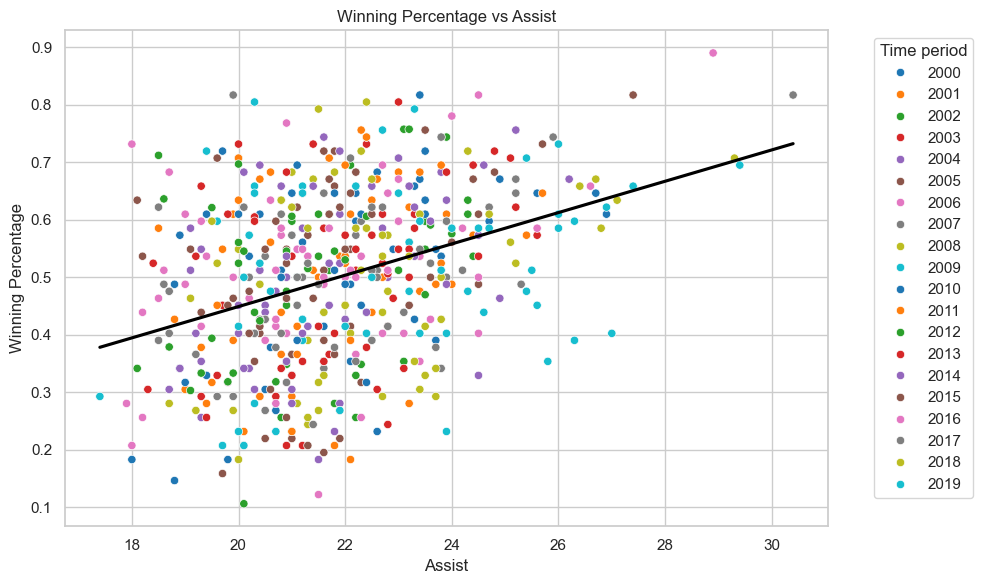

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'year' column exists and is string type
data['year'] = data['yearID'].astype(str)

sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='AST', y='WP', hue='year', palette='tab10', legend='full')
sns.regplot(data=data, x='AST', y='WP', scatter=False, color='black', ci=None)

plt.xlabel("Assist")
plt.ylabel("Winning Percentage")
plt.title("Winning Percentage vs Assist")
plt.legend(title="Time period", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import statsmodels.formula.api as smf

# Make sure 'year' is categorical
data['year'] = data['yearID'].astype(str)

# Fit OLS regression with interaction term AST * year
regression = smf.ols('WP ~ AST * year', data=data).fit()

# Get tidy coefficients summary
model = regression.summary2().tables[1]

print(model)


                     Coef.  Std.Err.         t     P>|t|    [0.025    0.975]
Intercept        -0.568298  0.301359 -1.885787  0.059846 -1.160241  0.023645
year[T.2001]      0.477783  0.431206  1.108015  0.268335 -0.369213  1.324778
year[T.2002]      0.342450  0.493690  0.693654  0.488190 -0.627280  1.312180
year[T.2003]      0.391214  0.428776  0.912396  0.361957 -0.451009  1.233437
year[T.2004]      0.156207  0.434331  0.359650  0.719246 -0.696927  1.009341
year[T.2005]      0.745309  0.467123  1.595531  0.111163 -0.172236  1.662855
year[T.2006]      0.470237  0.410592  1.145265  0.252593 -0.336268  1.276742
year[T.2007]      0.453815  0.427952  1.060435  0.289408 -0.386788  1.294418
year[T.2008]      0.166699  0.419086  0.397769  0.690953 -0.656489  0.989887
year[T.2009]      0.208902  0.496019  0.421158  0.673803 -0.765402  1.183207
year[T.2010]      0.268265  0.445417  0.602279  0.547234 -0.606644  1.143175
year[T.2011]      0.264284  0.512179  0.515999  0.606060 -0.741762  1.270330

3.4.3

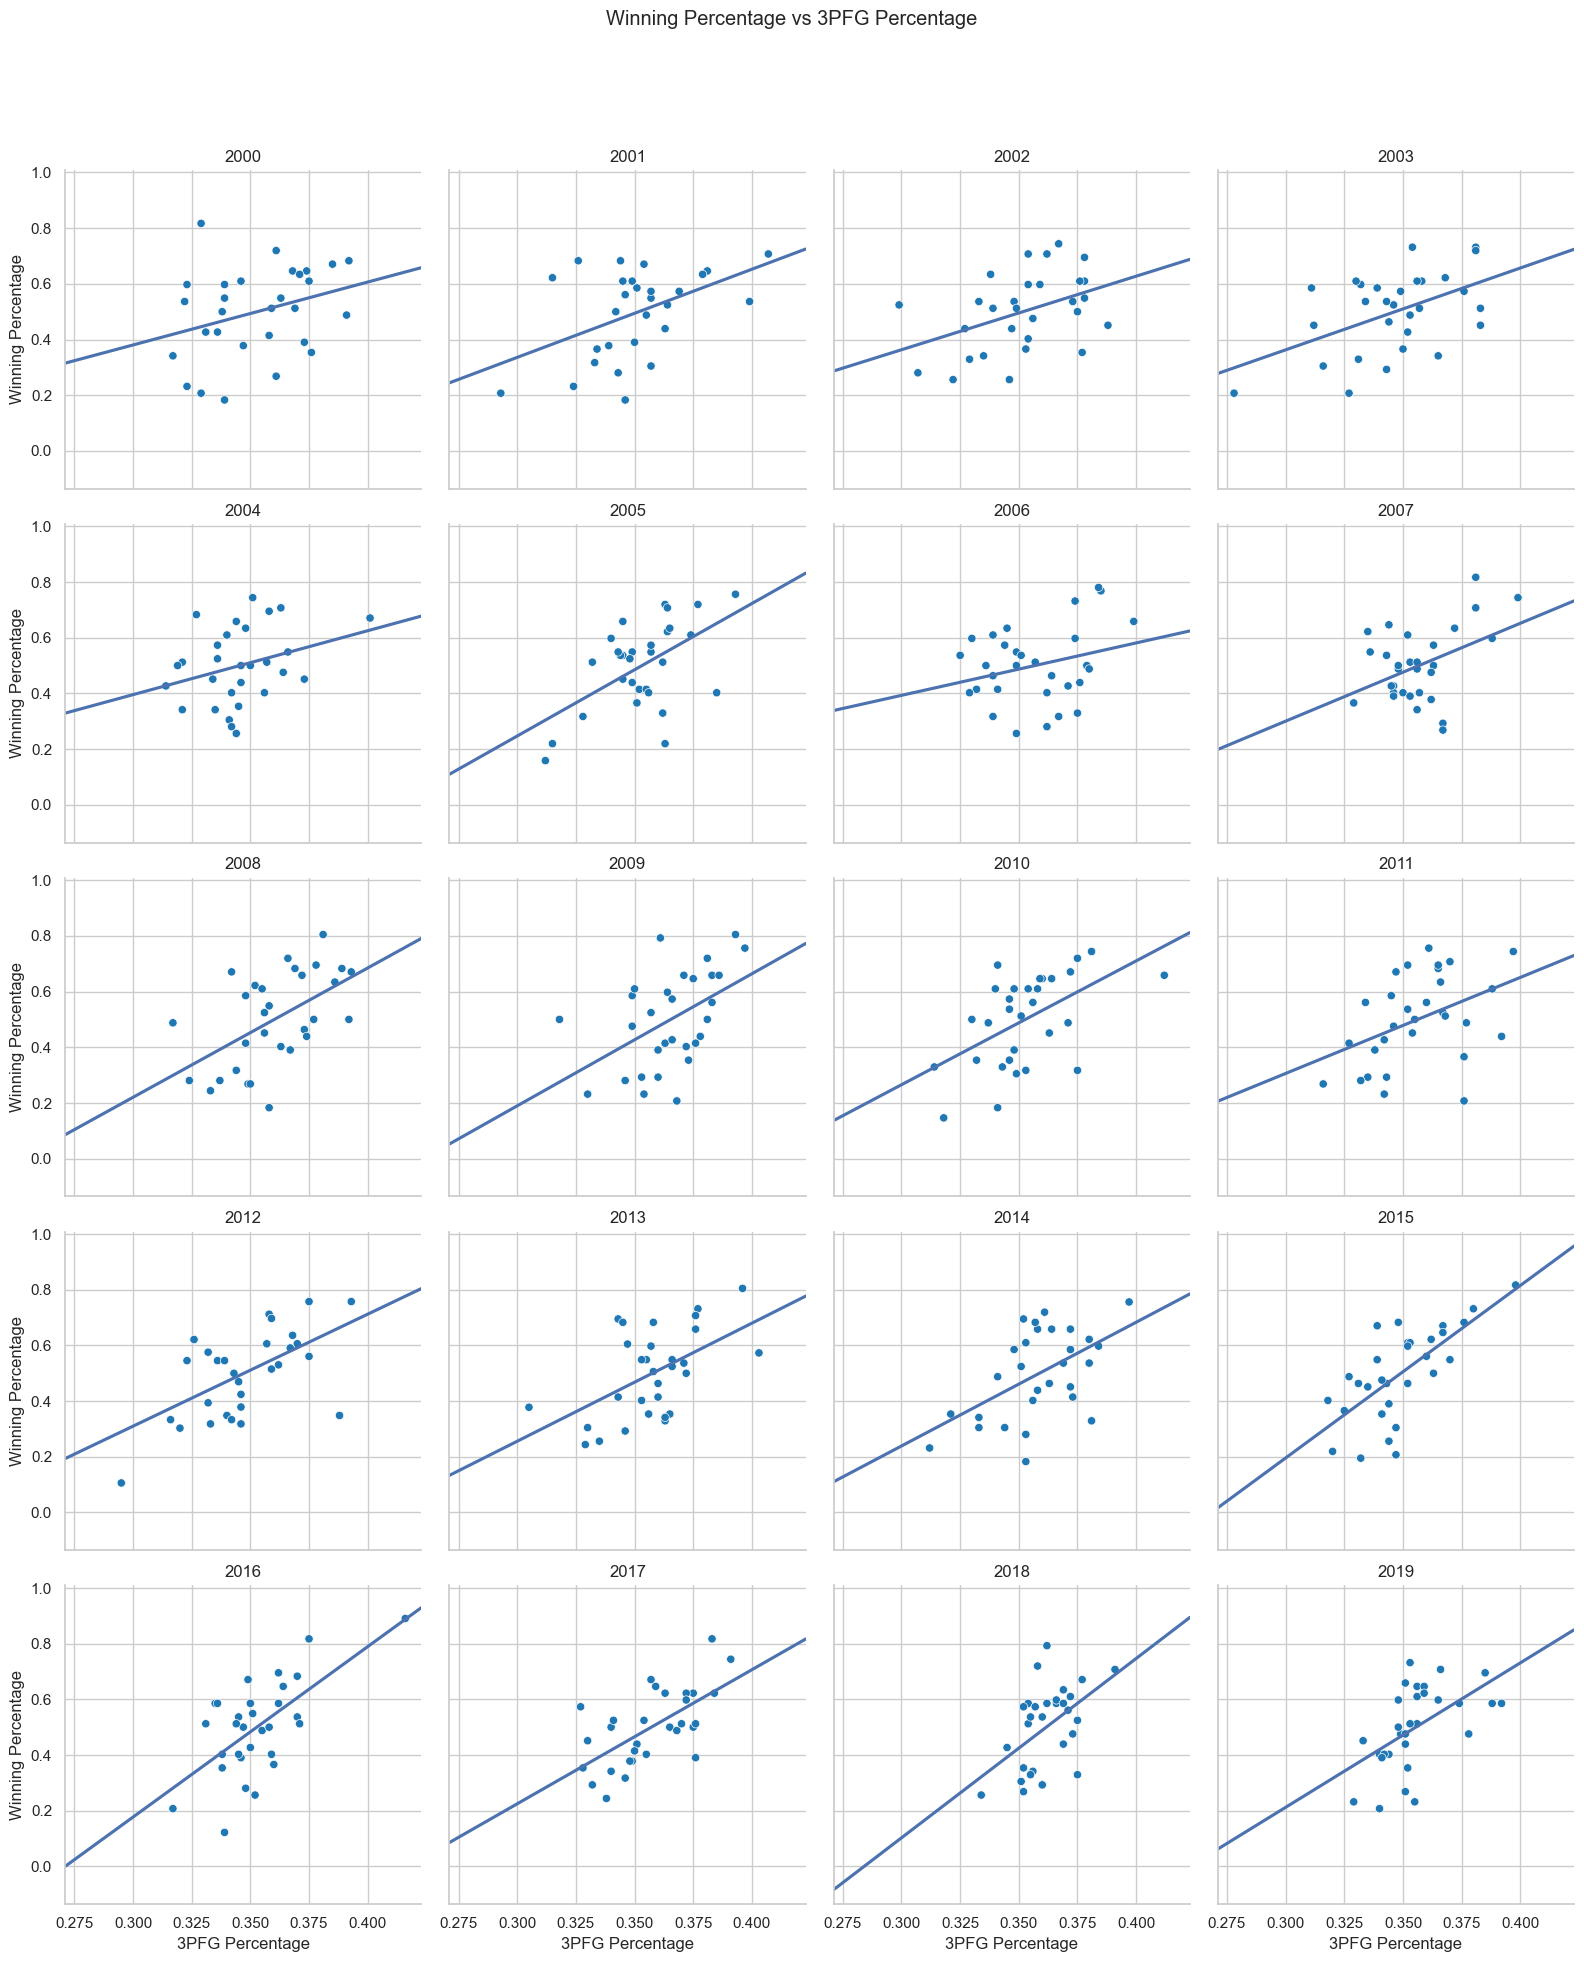

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Convert yearID to string for faceting
data['year'] = data['yearID'].astype(str)

sns.set(style="whitegrid")

# Create FacetGrid with one plot per year
g = sns.FacetGrid(data, col='year', col_wrap=4, height=4, sharex=True, sharey=True)

# Scatterplot with points colored by year (legend turned off to avoid repetition)
g.map_dataframe(sns.scatterplot, x='3P%', y='WP', hue='year', palette='tab10', legend=False)

# Add regression line per facet
def regplot_per_facet(data, color, **kwargs):
    sns.regplot(x='3P%', y='WP', data=data, scatter=False, color=color, ci=None, truncate=False, **kwargs)

g.map_dataframe(regplot_per_facet)

# Set axis labels and titles
g.set_axis_labels("3PFG Percentage", "Winning Percentage")
g.set_titles(col_template="{col_name}")

# Add overall title
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Winning Percentage vs 3PFG Percentage")

plt.show()


In [ ]:
import statsmodels.formula.api as smf

# Convert year to string for categorical interaction
data['year'] = data['yearID'].astype(str)

# Fit linear regression with interaction term
regression = smf.ols('WP ~ Q("3P") * year', data=data).fit()

# Extract tidy summary of coefficients
model = regression.summary2().tables[1]

print(model)


                         Coef.  Std.Err.         t     P>|t|    [0.025  \
Intercept             0.465027  0.112923  4.118105  0.000044  0.243219   
year[T.2001]         -0.244432  0.163476 -1.495220  0.135426 -0.565539   
year[T.2002]         -0.169741  0.154706 -1.097182  0.273038 -0.473622   
year[T.2003]         -0.120441  0.148140 -0.813023  0.416554 -0.411424   
year[T.2004]          0.017559  0.163906  0.107131  0.914724 -0.304392   
year[T.2005]         -0.195329  0.147425 -1.324941  0.185736 -0.484907   
year[T.2006]         -0.129570  0.153895 -0.841935  0.400187 -0.431858   
year[T.2007]         -0.190912  0.164072 -1.163590  0.245090 -0.513189   
year[T.2008]         -0.295108  0.163901 -1.800531  0.072320 -0.617050   
year[T.2009]         -0.243348  0.169675 -1.434205  0.152077 -0.576632   
year[T.2010]         -0.211424  0.164908 -1.282071  0.200353 -0.535343   
year[T.2011]         -0.173504  0.163976 -1.058107  0.290467 -0.495594   
year[T.2012]         -0.152749  0.1648

Machine Learning with Python


Model training & result interpretation

In [ ]:
import numpy as np
import sklearn.metrics
import seaborn as sns
import matplotlib.pylab as plt
import statsmodels.formula.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold

In [ ]:
sns.set(rc={'figure.figsize':(15,12)})

In [ ]:
tmp = df2.columns.tolist()[4:50]
train = df2[df2.yearID < 2019]
test = df2[df2.yearID == 2019]

x_train = train[tmp]
x_test = test[tmp]
y_train = train.home_win
y_test = test.home_win

In [ ]:
model = LogisticRegression(n_jobs=8)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
y_test_pred = model.predict(x_test)
y_train_pred = model.predict(x_train)

In [ ]:
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
score_trian = model.score(x_train, y_train)
score_test = model.score(x_test, y_test)

print("mse_train: {}\nmse_test: {}\nscore_trian: {}\nscore_test: {}\n".format(mse_train,mse_test,score_trian,score_test))

mse_train: 0.30265486725663715
mse_test: 0.2636363636363636
score_trian: 0.6973451327433628
score_test: 0.7363636363636363



In [ ]:
output = pd.DataFrame()

a_tmp = [-1 * x for x in model.coef_[0][1::2]]

output['attribute'] = title
output['h_weight'] = model.coef_[0][::2]
output['a_weight'] = a_tmp

output

,attribute,h_weight,a_weight
0,FG,0.224783,0.198880
1,FGA,-0.189661,-0.161353
2,FG%,0.003170,0.004053
3,3P,0.093544,0.079974
4,3PA,-0.045652,-0.083688
5,3P%,0.004173,0.008342
6,2P,0.146133,0.102506
7,2PA,-0.149594,-0.093267
8,2P%,0.002687,0.002044
9,FT,0.085037,0.101531


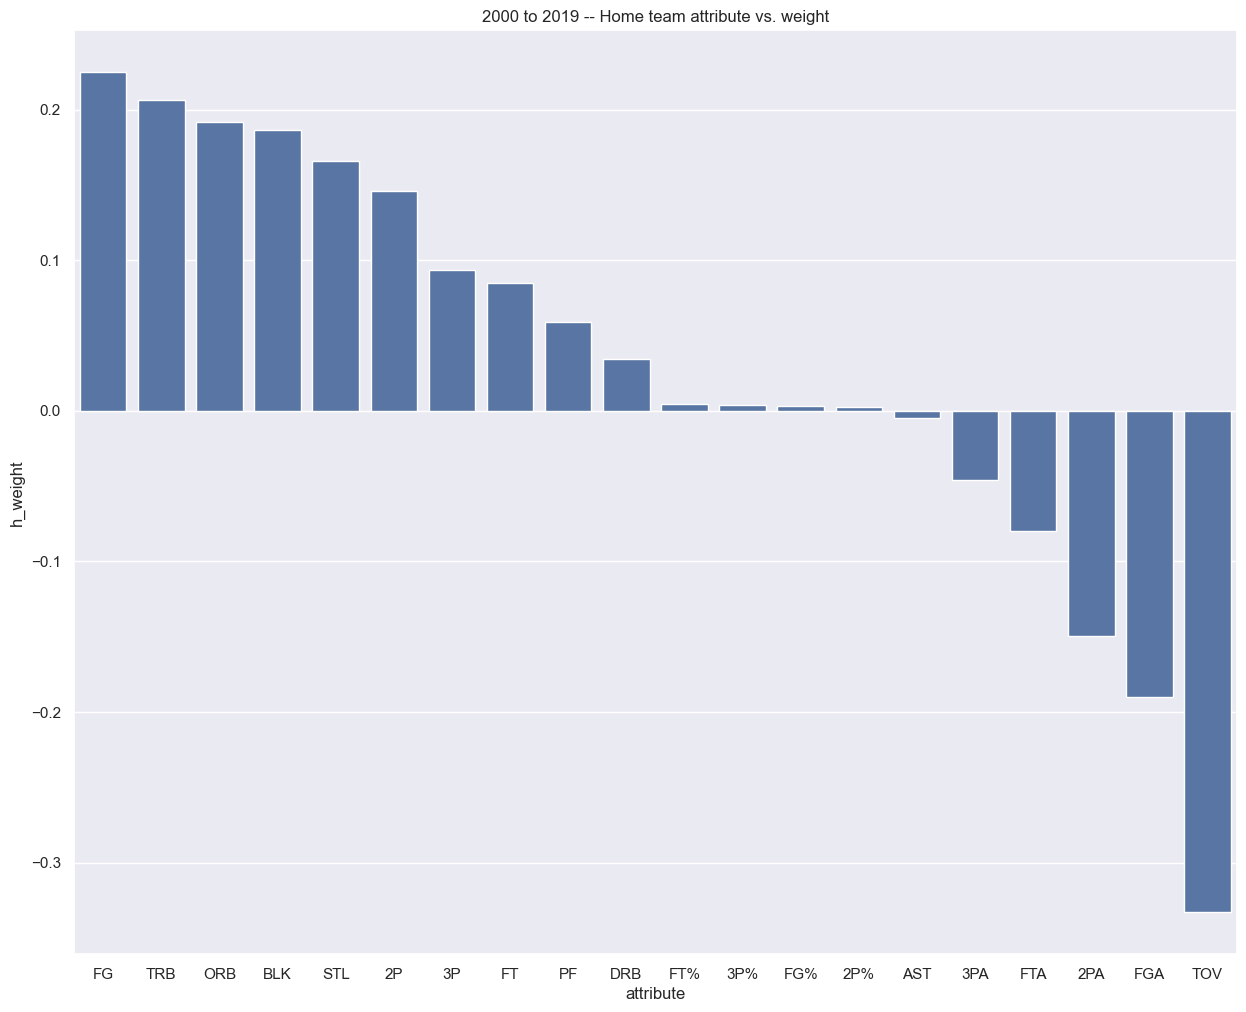

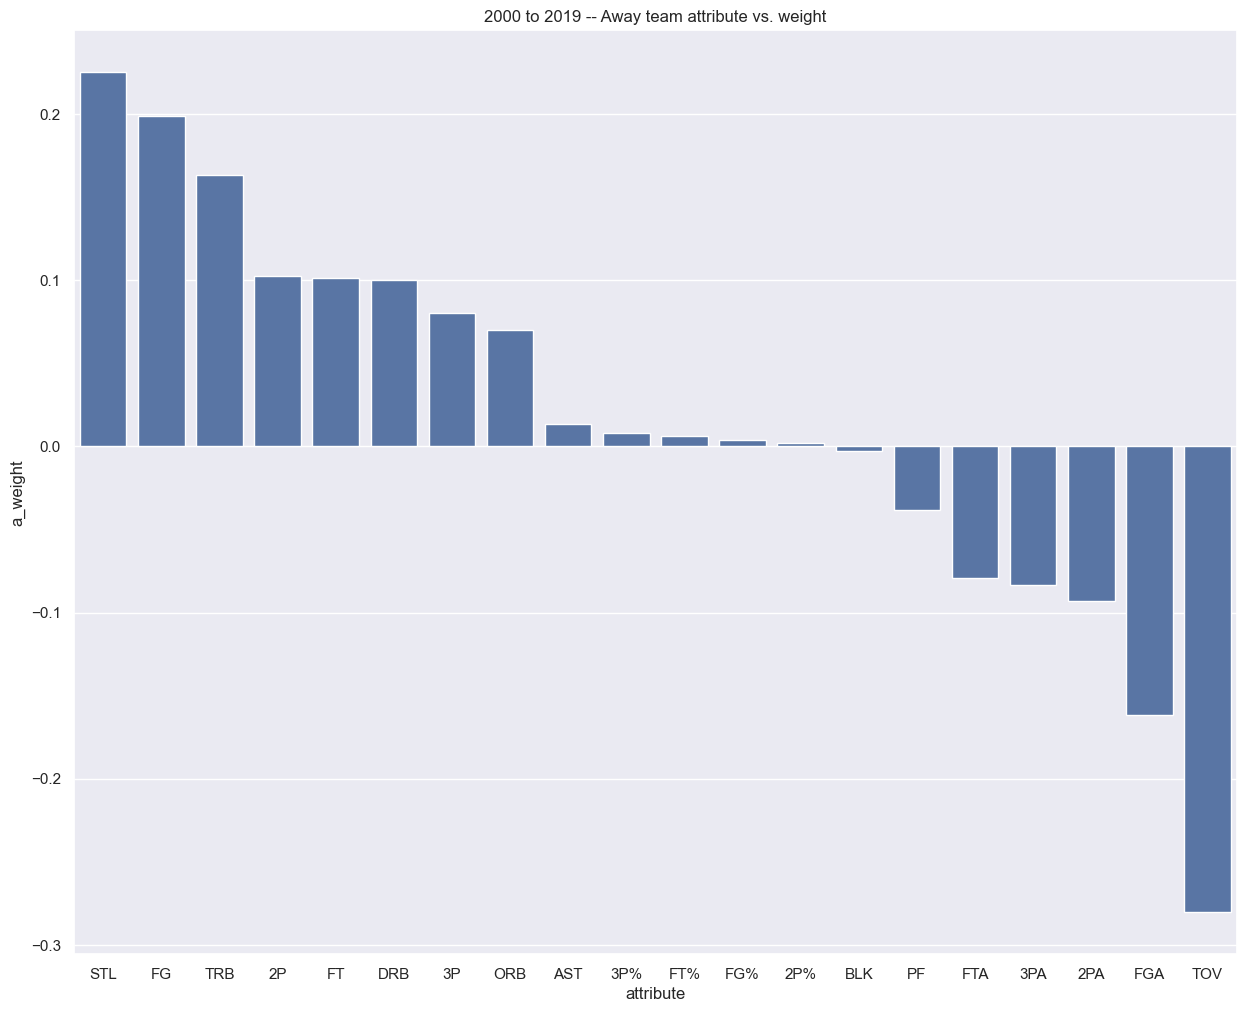

In [ ]:
sns.barplot(x = "attribute", y = "h_weight", data = output.sort_values(by=['h_weight'], ascending=False))
plt.title('2000 to 2019 -- Home team attribute vs. weight')
plt.show()
sns.barplot(x = "attribute", y = "a_weight", data = output.sort_values(by=['a_weight'], ascending=False))
plt.title('2000 to 2019 -- Away team attribute vs. weight')
plt.show()

In [ ]:
train = df2[(df2.yearID < 2019) & (df2.yearID >= 2014)]
test = df2[df2.yearID == 2019]

x_train = train[tmp]
x_test = test[tmp]
y_train = train.home_win
y_test = test.home_win

In [ ]:
model.fit(x_train, y_train)

y_test_pred = model.predict(x_test)
y_train_pred = model.predict(x_train)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
score_trian = model.score(x_train, y_train)
score_test = model.score(x_test, y_test)

print("mse_train: {}\nmse_test: {}\nscore_trian: {}\nscore_test: {}\n".format(mse_train,mse_test,score_trian,score_test))

mse_train: 0.3017241379310345
mse_test: 0.2909090909090909
score_trian: 0.6982758620689655
score_test: 0.7090909090909091



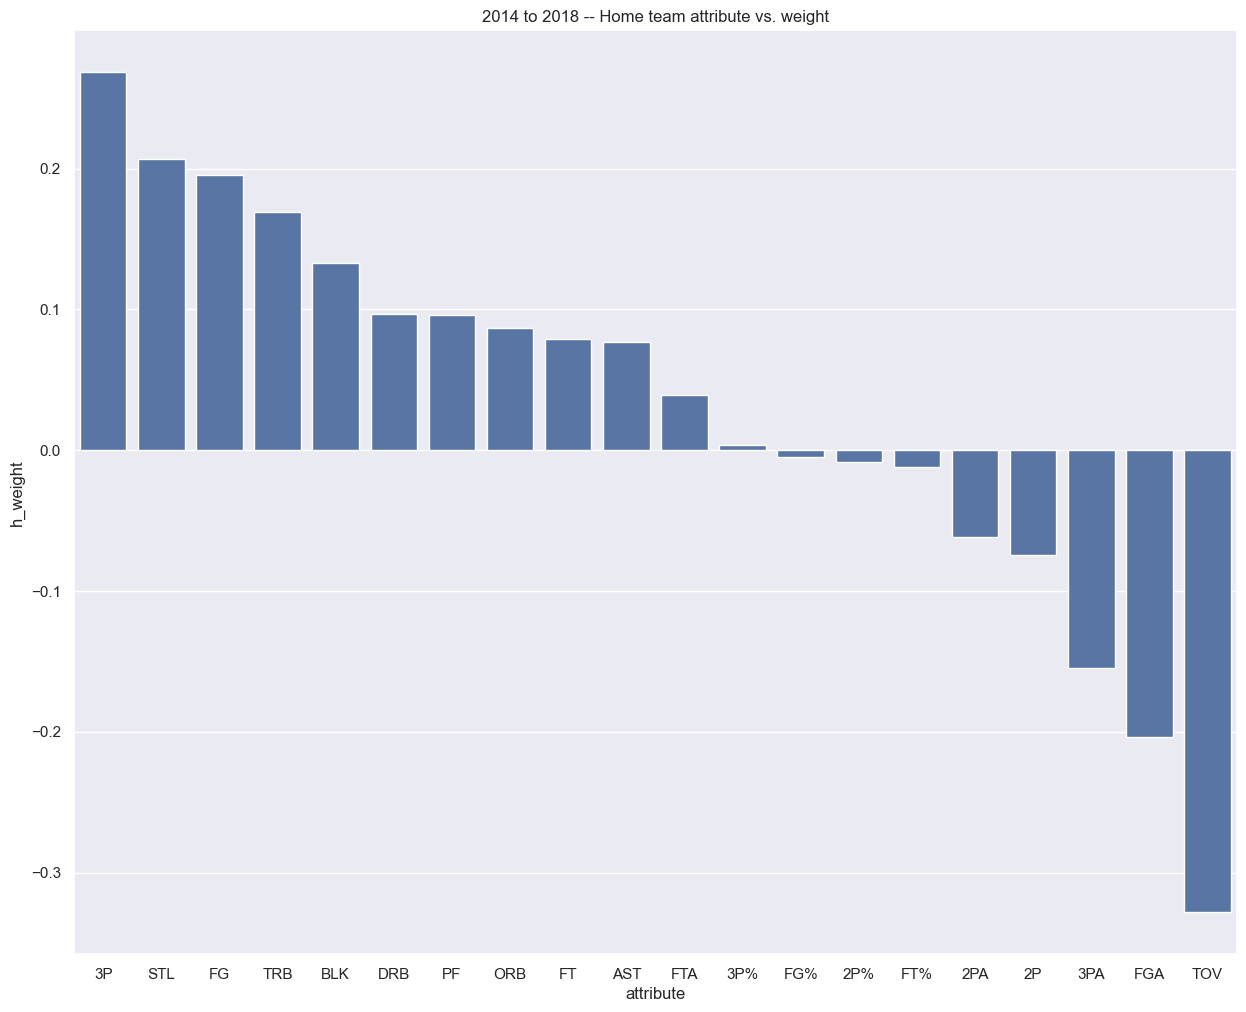

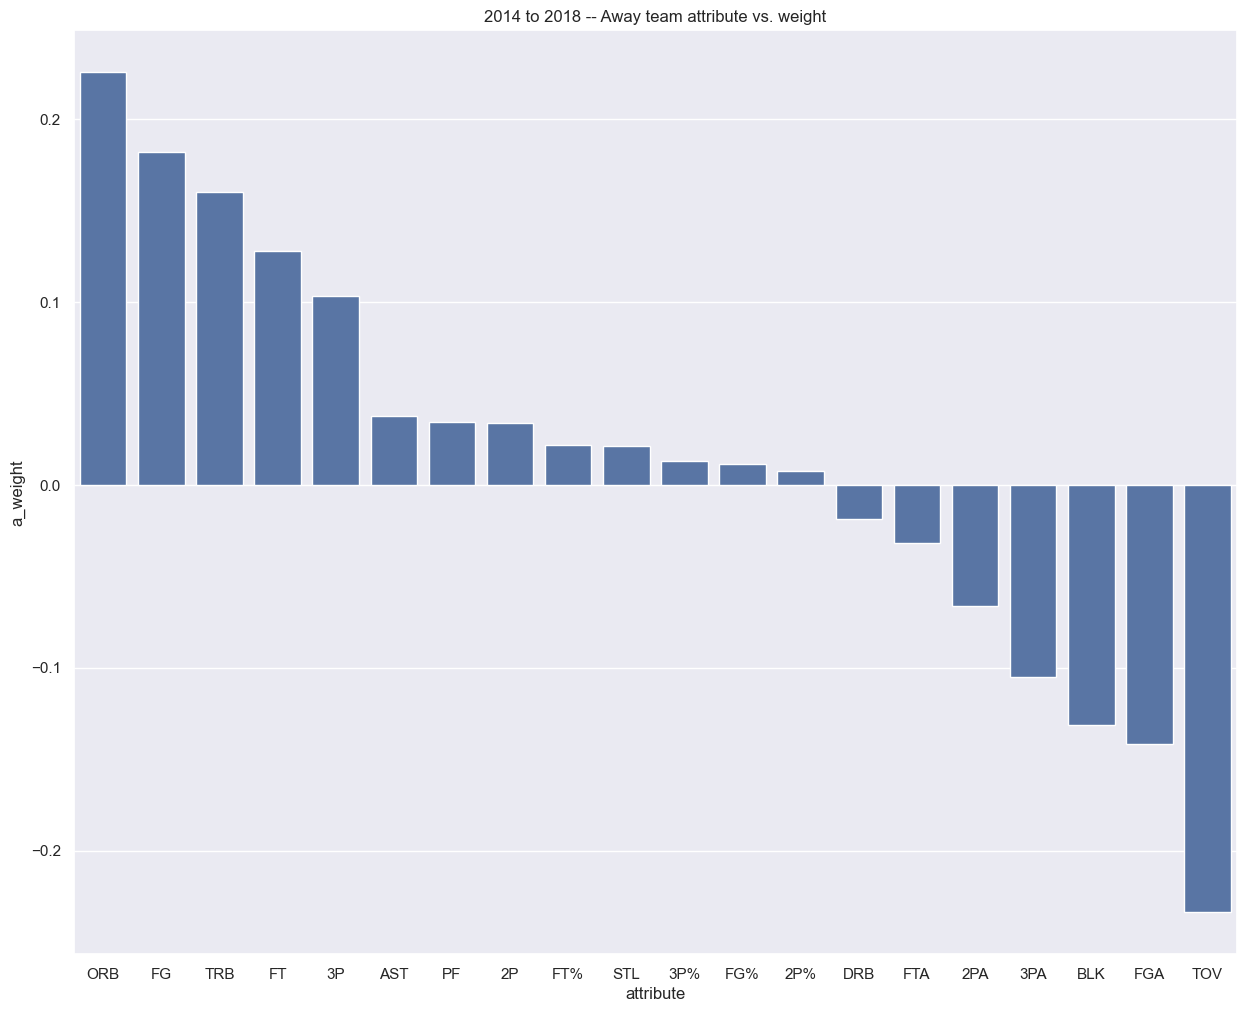

In [ ]:
output = pd.DataFrame()

a_tmp = [-1 * x for x in model.coef_[0][1::2]]

output['attribute'] = title
output['h_weight'] = model.coef_[0][::2]
output['a_weight'] = a_tmp

sns.barplot(x = "attribute", y = "h_weight", data = output.sort_values(by=['h_weight'], ascending=False))
plt.title('2014 to 2018 -- Home team attribute vs. weight')
plt.show()
sns.barplot(x = "attribute", y = "a_weight", data = output.sort_values(by=['a_weight'], ascending=False))
plt.title('2014 to 2018 -- Away team attribute vs. weight')
plt.show()